# Structure-Based Bioactivity Grading — Third Phase

Small-scale docking validation of the ML-QSAR selected compounds.

Runs locally on a personal computer (<20min runtime, 80 compounds).

**Inputs:**
- `Imidazolones_30samples.csv` (ID, SMILES, QSAR_score)
- `Thiazolones_15samples.csv` (ID, SMILES, QSAR_score)
- `6COX.pdb` (COX-2, ligand S58)
- `3KK6.pdb` (COX-1, ligand FLC)

**Workflow:**
1. **PREPARE** — Ligand (multi-conformer) + receptor preparation
2. **DOCK** — AutoDock Vina (exhaustiveness=16, num_modes=3)
3. **SCORE** — Geometric scoring, pose selection, final ranking

***(Please read [the third phase README.md](03_docking_pdbqts_data/README.md) for full details on this notebook).***


In [11]:
import sys
import pandas as pd

sys.path.insert(0, "03_docking_pdbqts_data")
from modules import docking as dock

cfg = dock.get_docking_config()
dirs = dock.init_hpc_dirs(
    cfg["ROOT"] / "03_docking_pdbqts_data/.interim",
    receptor_ids=["6COX", "3KK6"],
)

[init_hpc_dirs] Created 7 directories under 03_docking_pdbqts_data/.interim


## 📥 17. Load input compounds

Load the QSAR-prioritized compounds from file.
Thiazolones and imidazolones are loaded separately then concatenated.


In [12]:
df_ligands_raw = dock.load_ligands([
    cfg["INPUT_CSV_THIAZOLONES"],
    cfg["INPUT_CSV_IMIDAZOLONES"],
])
display(df_ligands_raw[["ID", "SMILES", "QSAR_score"]].head())

[Load ligands] 24 compounds total


,ID,SMILES,QSAR_score
0,A113C502S,Cc1ccc(O)c(/C=C2\N=C(c3ccc(F)cc3C(F)(F)F)SC2=O)c1,6.312123
1,A29C362S,O=C1SC(c2cc(F)cc(F)c2)=N/C1=C\c1cccs1,5.555026
2,A31C127S,COC(=O)c1ccc(/C=C2\N=C(c3ccc(C)s3)SC2=O)cc1,4.672889
3,A113C561S,Cc1ccc(O)c(/C=C2\N=C(c3ccc(F)cc3Br)SC2=O)c1,6.551371
4,A31C362S,COC(=O)c1ccc(/C=C2\N=C(c3cc(F)cc(F)c3)SC2=O)cc1,8.273290


## ⬥ 18. Prepare ligands (multi-conformer)

Generate RDKit multi-conformer structures for flexible docking.


In [13]:
df_ligands = dock.prepare_ligands_multi_conf(
    df_ligands_raw, dirs["ligands"], n_confs=15, seed=42,
)

[prepare_ligands_multi_conf] 24/24 ligands prepared successfully


## ⬥ 19. Prepare receptors

Prepare COX-2 (6COX) and COX-1 (3KK6) with binding site boxes.


In [14]:
cox2_info, cox1_info = dock.prepare_all_receptors(dirs, cfg)

[prepare_receptor] Generated 03_docking_pdbqts_data/.interim/receptors/6COX.pdbqt
[prepare_receptor] Using overridden box for 6COX: center=[26.5, 23.5, 48.3]
[prepare_receptor] Saved 03_docking_pdbqts_data/.interim/receptors/6COX_box.json
[prepare_receptor] Generated 03_docking_pdbqts_data/.interim/receptors/3KK6.pdbqt
[get_binding_site_center] Using FLC centroid from 3KK6.pdb
[prepare_receptor] Saved 03_docking_pdbqts_data/.interim/receptors/3KK6_box.json

6COX:
  Center: (26.5, 23.5, 48.3)
  Size: 22.0 x 22.0 x 22.0 A

3KK6:
  Center: (-41.061, 66.59, -1.471)
  Size: 22.0 x 22.0 x 22.0 A


## 🔹 20. Run docking

Create ligand–receptor mapping and run AutoDock Vina locally.


In [15]:
mapping_df, docking_stats = dock.run_docking_workflow(
    df_ligands, dirs, exhaustiveness=16, num_modes=3, seed=42,
)

[write_mapping_csv] 48 docking tasks written to 03_docking_pdbqts_data/.interim/mapping.csv
[docking mapping] 48 tasks
[docking] Using Vina at: vina
  [1/48] A113C502S x 6COX done
  [2/48] A113C502S x 3KK6 done
  [3/48] A29C362S x 6COX done
  [4/48] A29C362S x 3KK6 done
  [5/48] A31C127S x 6COX done
  [6/48] A31C127S x 3KK6 done
  [7/48] A113C561S x 6COX done
  [8/48] A113C561S x 3KK6 done
  [9/48] A31C362S x 6COX done
  [10/48] A31C362S x 3KK6 done
  [11/48] A97C141S x 6COX done
  [12/48] A97C141S x 3KK6 done
  [13/48] A31C561S x 6COX done
  [14/48] A31C561S x 3KK6 done
  [15/48] A113C177S x 6COX done
  [16/48] A113C177S x 3KK6 done
  [17/48] A67C77S x 6COX done
  [18/48] A67C77S x 3KK6 done
  [19/48] A31C141N76 x 6COX done
  [20/48] A31C141N76 x 3KK6 done
  [21/48] A29C141N261 x 6COX done
  [22/48] A29C141N261 x 3KK6 done
  [23/48] A31C77N76 x 6COX done
  [24/48] A31C77N76 x 3KK6 done
  [25/48] A31C141N313 x 6COX done
  [26/48] A31C141N313 x 3KK6 done
  [27/48] A36C141N247 x 6COX don

## ⬥ 21. Validate and parse results

Check docking completion and extract all ligand poses.


In [16]:
df_all_poses = dock.validate_and_extract(
    dirs, ["6COX", "3KK6"], cfg["RECEPTOR_MAP"], num_modes=3,
)
if not df_all_poses.empty:
    display(df_all_poses.head(10))

[validate_docking] PARTIAL: 24/48 docking tasks validated. Missing: 24, Failed: 0, Orphaned: 0 | Missing tasks: [('A67C362N76', '3KK6'), ('A113C177S', '3KK6'), ('A29C141N261', '3KK6'), ('A67C561N101', '3KK6'), ('A29C362S', '3KK6')]...
[validate_docking] PARTIAL: 24/48 docking tasks validated. Missing: 24, Failed: 0, Orphaned: 0 | Missing tasks: [('A67C561N101', '6COX'), ('A31C141N313', '6COX'), ('A67C77S', '6COX'), ('A31C362N76', '6COX'), ('A31C141N247', '6COX')]...

Partial results: 48/96 tasks validated.
Downstream analysis will use only validated tasks.
[parse poses] 144 poses extracted (3 per task max)


,ligand_id,receptor_id,cox_label,pose_rank,docking_score
0,A31C362N76,6COX,COX2,1,-8.59
1,A31C362N76,6COX,COX2,2,-6.23
2,A31C362N76,6COX,COX2,3,-3.81
3,A31C141N313,6COX,COX2,1,-7.92
4,A31C141N313,6COX,COX2,2,-6.73
5,A31C141N313,6COX,COX2,3,-6.04
6,A67C362N76,6COX,COX2,1,-7.92
7,A67C362N76,6COX,COX2,2,-7.45
8,A67C362N76,6COX,COX2,3,-7.45
9,A31C362S,6COX,COX2,1,-8.39


## 🔸 22. Geometric scoring and pose selection

Select the best pose per compound using geometric criteria.


In [17]:
df_best_poses = dock.select_best_poses_across(
    df_all_poses, dirs, ["6COX", "3KK6"], cfg["receptor_pdb_map"],
)
if not df_best_poses.empty:
    display(df_best_poses.head(10))

    Arg120: interaction 2.83 A (+2)
    Side pocket: fraction=0.50 (+1)
    Clashes: 33 (running score: 1.0)
    Arg120: interaction 2.83 A (+2)
    Side pocket: fraction=0.50 (+1)
    Clashes: 33 (running score: 1.0)
    Arg120: interaction 2.83 A (+2)
    Side pocket: fraction=0.50 (+1)
    Clashes: 33 (running score: 1.0)
    Arg120: interaction 2.88 A (+2)
    Tyr355: interaction 2.86 A (+2)
    Side pocket: fraction=0.56 (+1)
    Clashes: 50 (running score: 3.0)
    Arg120: interaction 2.88 A (+2)
    Tyr355: interaction 2.86 A (+2)
    Side pocket: fraction=0.56 (+1)
    Clashes: 50 (running score: 3.0)
    Arg120: interaction 2.88 A (+2)
    Tyr355: interaction 2.86 A (+2)
    Side pocket: fraction=0.56 (+1)
    Clashes: 50 (running score: 3.0)
    Arg120: interaction 2.76 A (+2)
    Tyr355: interaction 3.42 A (+2)
    Side pocket: fraction=0.57 (+1)
    Clashes: 53 (running score: 3.0)
    Arg120: interaction 2.76 A (+2)
    Tyr355: interaction 3.42 A (+2)
    Side pocket: frac

,ligand_id,receptor_id,cox_label,best_pose_rank,docking_score,geometric_score
0,A31C362N76,6COX,COX2,1,-8.59,1.0
1,A31C141N313,6COX,COX2,1,-7.92,3.0
2,A67C362N76,6COX,COX2,1,-7.92,3.0
3,A31C362S,6COX,COX2,1,-8.39,3.0
4,A29C362N101,6COX,COX2,1,-8.16,3.0
5,A67C141N247,6COX,COX2,1,-8.26,3.0
6,A34C141N277,6COX,COX2,1,-8.16,3.0
7,A31C141N76,6COX,COX2,1,-7.49,1.0
8,A31C77N76,6COX,COX2,1,-6.96,3.0
9,A113C561S,6COX,COX2,1,-8.75,3.0


## ⬥ 24. Final ranking

Combine QSAR scores with docking scores into a unified ranking.


In [18]:
df_ranked = dock.compute_final_ranking(df_best_poses, df_ligands_raw)
if not df_ranked.empty:
    cols = ["ligand_id", "QSAR_score", "score_cox2", "score_cox1",
            "geometric_score", "final_score"]
    display(df_ranked[[c for c in cols if c in df_ranked.columns]].round(4))

[compute_final_ranking] Scores computed for 24 compounds
[compute_final_ranking] Formula: final_score = 0.5*qsar_norm + 0.4*geo_norm + 0.1*vina_norm


,ligand_id,QSAR_score,score_cox2,score_cox1,final_score
0,A31C127S,4.6729,-7.44,-7.60,0.7783
1,A113C502S,6.3121,-9.35,-9.24,0.7783
2,A113C561S,6.5514,-8.75,-8.11,0.7435
3,A67C77S,5.6693,-7.36,-6.64,0.7217
4,A67C141N247,6.6117,-8.26,-7.46,0.7043
5,A113C177S,6.7032,-8.79,-8.10,0.6870
6,A34C141N277,6.7312,-8.16,-8.42,0.6326
7,A29C362S,5.5550,-8.40,-7.58,0.5913
8,A29C362N101,6.8806,-8.16,-7.22,0.5891
9,A31C77N76,6.8318,-6.96,-7.79,0.5565


## 📤 25. Output

Save the ranked scores and poses.


In [19]:
dock.save_all_outputs(
    df_ranked, dirs,
    cfg["ROOT"] / "03_docking_pdbqts_data/outputs",
)

[save_docking_scores] Saved 24 entries to 03_docking_pdbqts_data/outputs/docking_scores.csv
[poses] Poses saved to 03_docking_pdbqts_data/outputs/poses


## 🖼️ 26. Visualization (optional)

Render top-ranked poses with PyMOL.


[visualization] Rendering top 5 compounds (6COX)
[visualization] #1 A31C127S: saved A31C127S_6COX.png


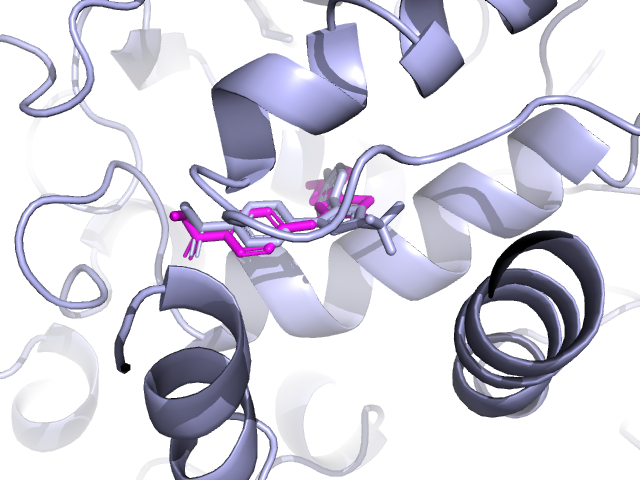

[visualization] #2 A113C502S: saved A113C502S_6COX.png


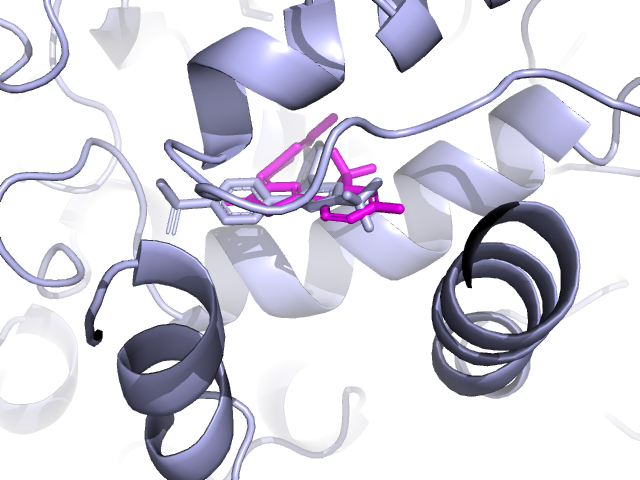

[visualization] #3 A113C561S: saved A113C561S_6COX.png


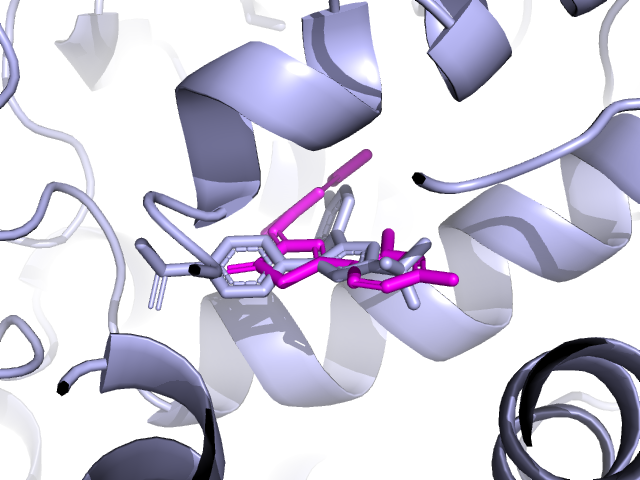

[visualization] #4 A67C77S: saved A67C77S_6COX.png


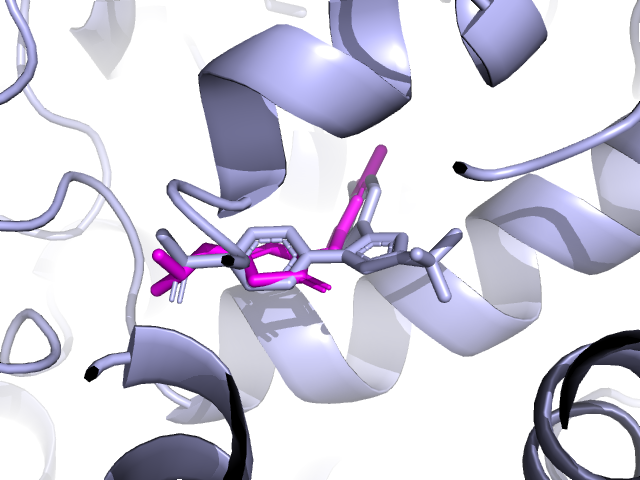

[visualization] #5 A67C141N247: saved A67C141N247_6COX.png


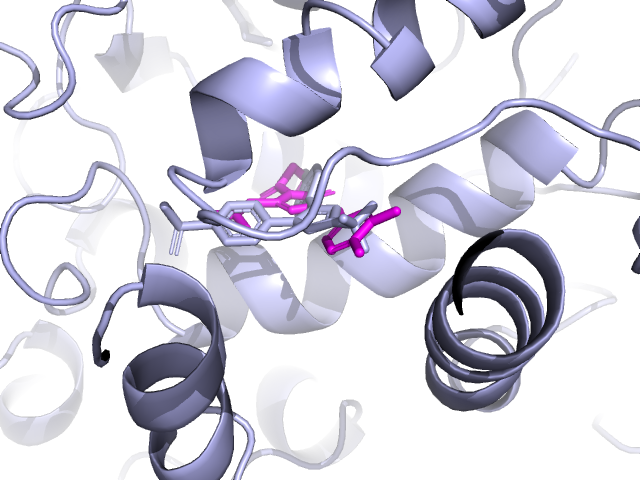

In [20]:
dock.render_top_poses(
    df_ranked, dirs, receptor_id="6COX",
    receptor_pdb=cfg["COX2_PDB"],
    output_dir=cfg["ROOT"] / "03_docking_pdbqts_data/outputs/figures",
    top_n=5,
)